# E-commerce Customer Segmentation & Lifecycle Analysis

## Business question

Customers should not be ranked by spend alone. The business also needs to distinguish consistently valuable customers, customers becoming dormant, newly acquired customers with potential, and low-engagement customers with cancellation signals.

This project builds customer features at a fixed observation cutoff and compares **K-Means, hierarchical clustering, Gaussian Mixture, and HDBSCAN**. Clustering uses only data available before the cutoff. Purchase behavior during the following 90 days is reserved for external validation.

## Project highlights

- Converts more than one million transaction lines into a customer feature layer;
- Combines RFM, lifecycle, purchase cadence, product diversity, recent trend, and cancellation behavior;
- Selects cluster count using silhouette, Davies–Bouldin, minimum segment size, and perturbation stability;
- Compares partitioning, hierarchical, probabilistic, and density-based clustering;
- Validates segments against observed purchasing behavior during the next 90 days;
- Produces operational profiles without claiming that clusters are naturally occurring customer personalities.


## 1. Data source and interpretation boundary

The data come from **Online Retail II** in the UCI Machine Learning Repository. They describe transactions from a UK-based non-store retailer between 1 December 2009 and 9 December 2011.

- Official page: https://archive.ics.uci.edu/dataset/502/online+retail+ii
- DOI: https://doi.org/10.24432/C5CG6D
- License: CC BY 4.0

The public data contain only several thousand identifiable customers. This project demonstrates the segmentation methodology; it does not replace or substantiate the 150,000+ sample scale stated in professional experience.


In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")

search_roots = [Path.cwd(), *Path.cwd().parents]
PORTFOLIO_ROOT = next(
    root for root in search_roots
    if (root / "data/raw/online_retail_ii/online_retail_II.xlsx").exists()
)
DATA_PATH = PORTFOLIO_ROOT / "data/raw/online_retail_ii/online_retail_II.xlsx"
PROJECT_DIR = PORTFOLIO_ROOT / "projects/04_customer_analytics"
OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CUTOFF = pd.Timestamp("2011-09-01")
OBSERVATION_START = CUTOFF - pd.Timedelta(days=365)
VALIDATION_END = CUTOFF + pd.Timedelta(days=90)

print(f"Data file: {DATA_PATH.relative_to(PORTFOLIO_ROOT)}")
print(f"Observation window: {OBSERVATION_START.date()} to {CUTOFF.date()}(cutoff excluded)")
print(f"Future validation window: {CUTOFF.date()} to {VALIDATION_END.date()}(end excluded)")
display(Markdown(
    "**Result interpretation:** All clustering features come from before the observation cutoff; the following 90 days are used only for validation. "
    "This represents a monthly segmentation run on 1 September 2011, followed by a three-month outcome review."
))


Data file: data\raw\online_retail_ii\online_retail_II.xlsx
Observation window: 2010-09-01 to 2011-09-01(cutoff excluded)
Future validation window: 2011-09-01 to 2011-11-30(end excluded)


**Result interpretation:** All clustering features come from before the observation cutoff; the following 90 days are used only for validation. This represents a monthly segmentation run on 1 September 2011, followed by a three-month outcome review.

## 2. Read and clean the transactions, separating successful purchases from cancellations

In [2]:
sheets = pd.ExcelFile(DATA_PATH).sheet_names
raw = pd.concat([pd.read_excel(DATA_PATH, sheet_name=s) for s in sheets], ignore_index=True)
raw.columns = [
    "invoice", "stock_code", "description", "quantity",
    "invoice_date", "unit_price", "customer_id", "country"
]
raw["invoice_date"] = pd.to_datetime(raw["invoice_date"])
raw["invoice"] = raw["invoice"].astype(str).str.strip()
raw["stock_code"] = raw["stock_code"].astype(str).str.strip()
raw["is_cancelled"] = raw.invoice.str.upper().str.startswith("C") | (raw.quantity < 0)

identified = raw.loc[raw.customer_id.notna()].copy()
identified["customer_id"] = identified.customer_id.astype(int).astype(str)
successful = identified.loc[
    ~identified.is_cancelled & (identified.quantity > 0) & (identified.unit_price > 0)
].copy()
successful["revenue"] = successful.quantity * successful.unit_price
cancelled = identified.loc[identified.is_cancelled].copy()
cancelled["cancelled_value_abs"] = (cancelled.quantity * cancelled.unit_price).abs()

audit = pd.DataFrame({
    "Metric": ["Raw transaction lines", "Identifiable customers", "Missing customer-ID rate", "Successful-purchase lines", "Cancellation / negative-quantity lines"],
    "Result": [
        f"{len(raw):,}", f"{identified.customer_id.nunique():,}",
        f"{raw.customer_id.isna().mean():.2%}", f"{len(successful):,}", f"{len(cancelled):,}"
    ]
})
display(audit)
display(Markdown(
    f"**Result interpretation:** The raw data contain **{len(raw):,}** transaction lines and **{identified.customer_id.nunique():,}** identifiable customers. "
    f"The analysis uses **{len(successful):,}** successful-purchase lines; cancellations are retained separately as after-sales features. "
    "Transactions without a customer ID cannot be linked into customer histories, so they are excluded from segmentation while their missing rate remains visible in the audit."
))


,Metric,Result
0,Raw transaction lines,"1,067,371"
1,Identifiable customers,"5,942"
2,Missing customer-ID rate,22.77%
3,Successful-purchase lines,"805,549"
4,Cancellation / negative-quantity lines,"18,744"


**Result interpretation:** The raw data contain **1,067,371** transaction lines and **5,942** identifiable customers. The analysis uses **805,549** successful-purchase lines; cancellations are retained separately as after-sales features. Transactions without a customer ID cannot be linked into customer histories, so they are excluded from segmentation while their missing rate remains visible in the audit.

## 3. Build the customer feature layer

The observation window covers the previous 365 days so that old history does not accumulate without limit. A customer must have at least one successful purchase during this period.

- **Value and frequency:** orders, spend, units, and average order value;
- **Lifecycle:** recency, tenure, and active months;
- **Breadth:** distinct products and average lines per order;
- **Cadence and trend:** order gaps and recent 90-day shares;
- **After-sales behavior:** cancellation invoice rate and cancelled-value ratio.


In [3]:
history_all = successful.loc[successful.invoice_date < CUTOFF].copy()
obs = successful.loc[
    (successful.invoice_date >= OBSERVATION_START) & (successful.invoice_date < CUTOFF)
].copy()
obs_cancelled = cancelled.loc[
    (cancelled.invoice_date >= OBSERVATION_START) & (cancelled.invoice_date < CUTOFF)
].copy()

order_level = obs.groupby(["customer_id", "invoice"], as_index=False).agg(
    order_date=("invoice_date", "min"), order_value=("revenue", "sum"),
    order_units=("quantity", "sum"), order_lines=("stock_code", "size")
)
customers = order_level.groupby("customer_id").agg(
    orders_365d=("invoice", "nunique"), spend_365d=("order_value", "sum"),
    units_365d=("order_units", "sum"), avg_order_value=("order_value", "mean"),
    avg_lines_per_order=("order_lines", "mean"), last_purchase=("order_date", "max")
)
customers["recency_days"] = (CUTOFF - customers.last_purchase).dt.total_seconds() / 86400
first_purchase = history_all.groupby("customer_id").invoice_date.min()
customers["tenure_days"] = (CUTOFF - first_purchase.reindex(customers.index)).dt.total_seconds() / 86400
customers["active_months"] = obs.assign(month=obs.invoice_date.dt.to_period("M")).groupby("customer_id").month.nunique()
customers["distinct_skus"] = obs.groupby("customer_id").stock_code.nunique()

def order_gap_stats(group):
    dates = group.order_date.drop_duplicates().sort_values()
    gaps = dates.diff().dt.total_seconds().div(86400).dropna()
    return pd.Series({"mean_order_gap_days": gaps.mean(), "std_order_gap_days": gaps.std()})

customers = customers.join(order_level.groupby("customer_id", group_keys=False).apply(order_gap_stats))

recent_start = CUTOFF - pd.Timedelta(days=90)
recent = order_level.loc[order_level.order_date >= recent_start]
recent_agg = recent.groupby("customer_id").agg(
    recent_orders_90d=("invoice", "nunique"), recent_spend_90d=("order_value", "sum")
)
customers = customers.join(recent_agg, how="left").fillna({"recent_orders_90d": 0, "recent_spend_90d": 0})
customers["recent_order_share"] = customers.recent_orders_90d / customers.orders_365d.clip(lower=1)
customers["recent_spend_share"] = customers.recent_spend_90d / customers.spend_365d.clip(lower=0.01)

cancel_invoice = obs_cancelled.groupby("customer_id").invoice.nunique()
cancel_value = obs_cancelled.groupby("customer_id").cancelled_value_abs.sum()
customers["cancelled_invoice_rate"] = cancel_invoice.reindex(customers.index, fill_value=0) / (customers.orders_365d + cancel_invoice.reindex(customers.index, fill_value=0)).clip(lower=1)
customers["cancelled_value_ratio"] = cancel_value.reindex(customers.index, fill_value=0) / customers.spend_365d.clip(lower=0.01)
main_country = obs.groupby("customer_id").country.agg(lambda s: s.mode().iat[0] if not s.mode().empty else "Unknown")
customers["is_uk"] = main_country.reindex(customers.index).eq("United Kingdom").astype(int)
customers = customers.drop(columns="last_purchase")

CLUSTER_FEATURES = [
    "recency_days", "tenure_days", "orders_365d", "spend_365d",
    "units_365d", "avg_order_value", "active_months", "distinct_skus",
    "avg_lines_per_order", "mean_order_gap_days", "std_order_gap_days",
    "recent_order_share", "recent_spend_share",
    "cancelled_invoice_rate", "cancelled_value_ratio"
]

summary = customers[CLUSTER_FEATURES].describe(percentiles=[.25, .5, .75, .99]).T
display(summary[["count", "mean", "50%", "75%", "99%", "max"]].style.format("{:,.2f}"))
display(Markdown(
    f"**Result interpretation:** The observation window contains **{len(customers):,}** eligible customers and **{len(CLUSTER_FEATURES)}** clustering features. "
    "Spend, orders, and cancelled value are strongly right-skewed, so raw values would allow a few extreme customers to dominate Euclidean distance. "
    "The next step applies 1st–99th percentile clipping, imputation, skew transformation, and standardization within the defined analytical pipeline."
))


,count,mean,50%,75%,99%,max
recency_days,"4,335.00",143.94,111.33,269.41,357.10,364.58
tenure_days,"4,335.00",404.37,429.41,574.47,638.44,638.68
orders_365d,"4,335.00",4.11,2.00,4.00,28.00,186.00
spend_365d,"4,335.00","1,981.95",665.78,"1,621.15","18,562.11","268,575.55"
units_365d,"4,335.00","1,165.95",370.00,935.50,"10,642.84","191,529.00"
avg_order_value,"4,335.00",413.40,300.65,445.67,"1,998.06","77,183.60"
active_months,"4,335.00",2.86,2.00,4.00,12.00,12.00
distinct_skus,"4,335.00",58.75,34.00,73.00,340.32,"1,647.00"
avg_lines_per_order,"4,335.00",22.86,17.50,29.00,107.83,219.00
mean_order_gap_days,"2,760.00",68.43,51.10,90.60,285.95,336.02


**Result interpretation:** The observation window contains **4,335** eligible customers and **15** clustering features. Spend, orders, and cancelled value are strongly right-skewed, so raw values would allow a few extreme customers to dominate Euclidean distance. The next step applies 1st–99th percentile clipping, imputation, skew transformation, and standardization within the defined analytical pipeline.

## 4. Preprocessing: control extreme values and make distance scales comparable

In [4]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

feature_frame = customers[CLUSTER_FEATURES].replace([np.inf, -np.inf], np.nan).copy()
caps = feature_frame.quantile(0.99)
floors = feature_frame.quantile(0.01)
feature_capped = feature_frame.clip(lower=floors, upper=caps, axis=1)

imputer = SimpleImputer(strategy="median")
imputed = pd.DataFrame(imputer.fit_transform(feature_capped), index=feature_capped.index, columns=CLUSTER_FEATURES)
LOG_FEATURES = [
    "recency_days", "tenure_days", "orders_365d", "spend_365d", "units_365d",
    "avg_order_value", "active_months", "distinct_skus", "avg_lines_per_order",
    "mean_order_gap_days", "std_order_gap_days", "cancelled_value_ratio"
]
transformed = imputed.copy()
transformed[LOG_FEATURES] = np.log1p(transformed[LOG_FEATURES].clip(lower=0))
scaler = StandardScaler()
X = scaler.fit_transform(transformed)

check = pd.DataFrame({
    "Check": ["Customers", "Features", "Missing values after preprocessing", "Maximum absolute standardized mean", "Standardized standard-deviation range"],
    "Result": [len(customers), len(CLUSTER_FEATURES), int(np.isnan(X).sum()),
             float(np.abs(X.mean(axis=0)).max()), f"{X.std(axis=0).min():.3f}–{X.std(axis=0).max():.3f}"]
})
display(check)
display(Markdown(
    "**Result interpretation:** Preprocessing leaves no missing values and places every feature on a comparable scale. "
    "The 1st–99th percentile clipping does not remove customers; it only limits the influence of extreme values. The `log1p` transform preserves ordering while compressing long tails."
))


,Check,Result
0,Customers,4335
1,Features,15
2,Missing values after preprocessing,0
3,Maximum absolute standardized mean,0.000
4,Standardized standard-deviation range,1.000–1.000


**Result interpretation:** Preprocessing leaves no missing values and places every feature on a comparable scale. The 1st–99th percentile clipping does not remove customers; it only limits the influence of extreme values. The `log1p` transform preserves ordering while compressing long tails.

## 5. K-Means: select an operational cluster count

The candidate range is two to eight clusters.

- **Silhouette:** higher is better;
- **Davies–Bouldin:** lower is better;
- **Perturbation stability:** ARI between original labels and labels after small feature perturbations; closer to one is better;
- **Minimum segment share:** avoids tiny groups that are difficult to operationalize.

To balance statistical quality with operational interpretability, the final choice is ranked among four- to six-cluster solutions whose smallest segment represents at least 3% of customers.


  File "C:\Users\J\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


,k,silhouette,davies_bouldin,calinski_harabasz,stability_ari,min_cluster_share,rank_score
0,2,0.228,1.659,"1,253",0.987,38.9%,11.0
1,3,0.270,1.376,"1,221",0.990,11.7%,3.0
2,4,0.199,1.617,"1,070",0.970,10.5%,18.0
3,5,0.224,1.501,991,0.974,9.5%,13.0
4,6,0.196,1.466,964,0.975,2.7%,15.0
5,7,0.203,1.456,900,0.977,2.4%,11.0
6,8,0.204,1.395,854,0.916,2.3%,13.0


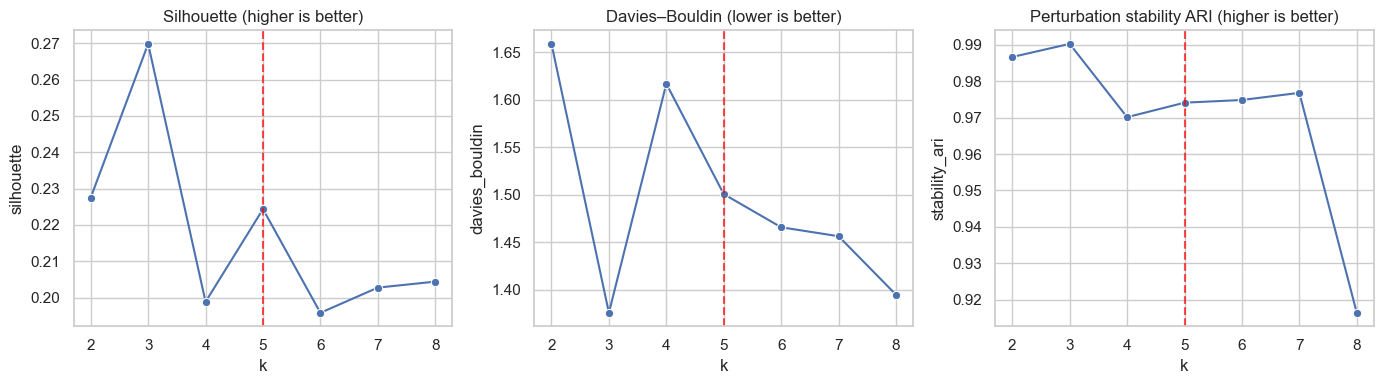

**Result interpretation:** Balancing statistical quality, stability, and operational granularity, the analysis selects **5 clusters**。The solution has a silhouette score of **0.224**, a stability ARI of **0.974**，and a minimum segment share of **9.5%**。The choice does not maximize a single metric: too few clusters can hide lifecycle differences, while too many can reduce stability and operational usability. The modest silhouette score indicates only moderate-to-weak natural separation, so the five segments should be interpreted as a useful operational simplification rather than five naturally occurring customer types.

In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    adjusted_rand_score
)

rng = np.random.default_rng(42)
k_rows = []
for k in range(2, 9):
    base = KMeans(n_clusters=k, n_init=30, random_state=42).fit(X)
    labels = base.labels_
    stability = []
    for repeat in range(6):
        noisy_X = X + rng.normal(0, 0.03, size=X.shape)
        noisy_labels = KMeans(n_clusters=k, n_init=15, random_state=100 + repeat).fit_predict(noisy_X)
        stability.append(adjusted_rand_score(labels, noisy_labels))
    shares = pd.Series(labels).value_counts(normalize=True)
    k_rows.append({
        "k": k, "silhouette": silhouette_score(X, labels),
        "davies_bouldin": davies_bouldin_score(X, labels),
        "calinski_harabasz": calinski_harabasz_score(X, labels),
        "stability_ari": np.mean(stability), "min_cluster_share": shares.min()
    })

k_selection = pd.DataFrame(k_rows)
k_selection["rank_score"] = (
    k_selection.silhouette.rank(ascending=False) +
    k_selection.davies_bouldin.rank(ascending=True) +
    k_selection.stability_ari.rank(ascending=False)
)
viable = k_selection.query("4 <= k <= 6 and min_cluster_share >= 0.03")
if viable.empty:
    viable = k_selection.query("min_cluster_share >= 0.03")
SELECTED_K = int(viable.sort_values(["rank_score", "silhouette"]).iloc[0].k)

display(k_selection.style.format({
    "silhouette": "{:.3f}", "davies_bouldin": "{:.3f}",
    "calinski_harabasz": "{:,.0f}", "stability_ari": "{:.3f}",
    "min_cluster_share": "{:.1%}", "rank_score": "{:.1f}"
}))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.lineplot(data=k_selection, x="k", y="silhouette", marker="o", ax=axes[0])
sns.lineplot(data=k_selection, x="k", y="davies_bouldin", marker="o", ax=axes[1])
sns.lineplot(data=k_selection, x="k", y="stability_ari", marker="o", ax=axes[2])
axes[0].set_title("Silhouette (higher is better)")
axes[1].set_title("Davies–Bouldin (lower is better)")
axes[2].set_title("Perturbation stability ARI (higher is better)")
for ax in axes: ax.axvline(SELECTED_K, ls="--", color="red", alpha=.7)
plt.tight_layout(); plt.show()

k_selection.to_csv(OUTPUT_DIR / "kmeans_k_selection.csv", index=False)
selected_row = k_selection.set_index("k").loc[SELECTED_K]
display(Markdown(
    f"**Result interpretation:** Balancing statistical quality, stability, and operational granularity, the analysis selects **{SELECTED_K} clusters**。"
    f"The solution has a silhouette score of **{selected_row.silhouette:.3f}**, a stability ARI of **{selected_row.stability_ari:.3f}**，"
    f"and a minimum segment share of **{selected_row.min_cluster_share:.1%}**。"
    "The choice does not maximize a single metric: too few clusters can hide lifecycle differences, while too many can reduce stability and operational usability. "
    "The modest silhouette score indicates only moderate-to-weak natural separation, so the five segments should be interpreted as a useful operational simplification rather than five naturally occurring customer types."
))


## 6. Compare K-Means, hierarchical clustering, Gaussian Mixture, and HDBSCAN

,algorithm,clusters,silhouette,davies_bouldin,calinski_harabasz,min_cluster_share,noise_share
0,K-Means,5,0.225,1.500,991,9.5%,0.0%
1,Hierarchical (Ward),5,0.212,1.390,838,1.6%,0.0%
2,Gaussian Mixture,5,0.154,1.900,808,9.1%,0.0%
3,HDBSCAN,4,0.259,1.199,750,8.9%,68.3%


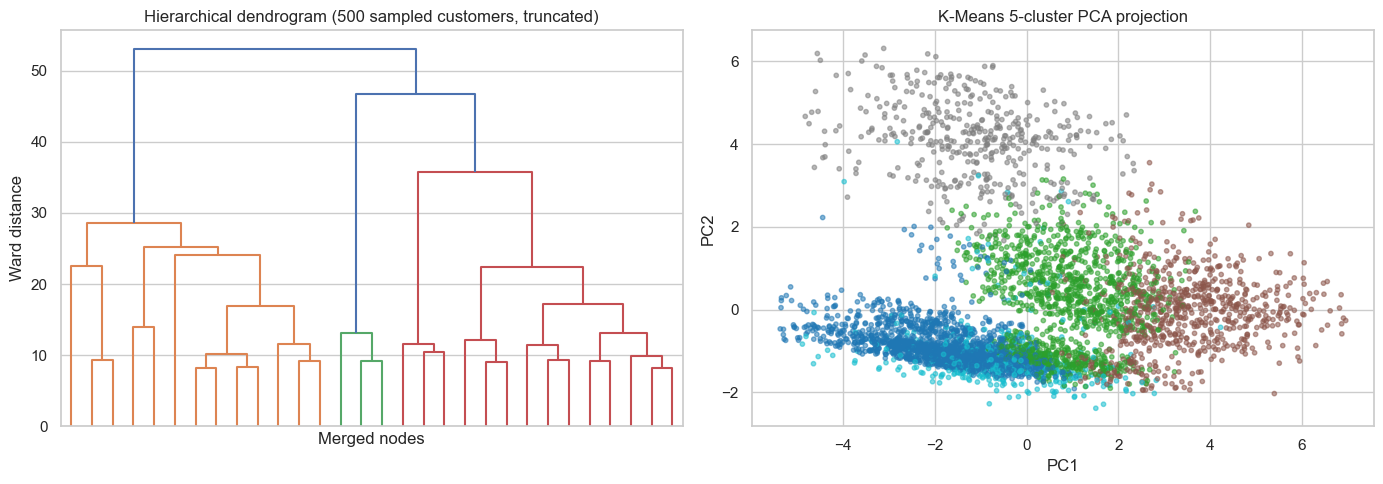

**Result interpretation:** All four algorithms use exactly the same preprocessed features. The label agreement ARI between K-Means and Ward hierarchical clustering is **0.532**；HDBSCAN identifies **4** non-noise clusters and labels **68.3%** of customers as noise. Ward hierarchical clustering produces a smallest segment of only **1.6%**, while HDBSCAN has an excessive noise share; neither is suitable as the primary operational solution. The PCA chart is only a two-dimensional projection of a 15-dimensional structure, so overlap in the plot does not imply that the original space contains no separation. K-Means is selected for operations because it is reproducible, can assign new customers to the nearest center, and directly demonstrates the resume methodology; hierarchical clustering provides a structural cross-check.

In [6]:
from sklearn.cluster import AgglomerativeClustering, HDBSCAN
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.decomposition import PCA

def algorithm_metrics(name, labels, noise_label=None):
    labels = np.asarray(labels)
    valid = np.ones(len(labels), dtype=bool) if noise_label is None else labels != noise_label
    valid_labels = labels[valid]
    n_clusters = len(np.unique(valid_labels))
    if n_clusters < 2:
        sil = db = ch = np.nan
    else:
        sil = silhouette_score(X[valid], valid_labels)
        db = davies_bouldin_score(X[valid], valid_labels)
        ch = calinski_harabasz_score(X[valid], valid_labels)
    shares = pd.Series(valid_labels).value_counts(normalize=True)
    return {
        "algorithm": name, "clusters": n_clusters, "silhouette": sil,
        "davies_bouldin": db, "calinski_harabasz": ch,
        "min_cluster_share": shares.min() if len(shares) else np.nan,
        "noise_share": 1 - valid.mean()
    }

kmeans = KMeans(n_clusters=SELECTED_K, n_init=50, random_state=42).fit(X)
agglomerative = AgglomerativeClustering(n_clusters=SELECTED_K, linkage="ward").fit(X)
gmm = GaussianMixture(n_components=SELECTED_K, covariance_type="full", n_init=5, random_state=42).fit(X)
hdbscan = HDBSCAN(min_cluster_size=max(40, int(len(X) * .02)), min_samples=15).fit(X)

algorithm_labels = {
    "K-Means": kmeans.labels_,
    "Hierarchical (Ward)": agglomerative.labels_,
    "Gaussian Mixture": gmm.predict(X),
    "HDBSCAN": hdbscan.labels_
}
algorithm_comparison = pd.DataFrame([
    algorithm_metrics(name, labels, -1 if name == "HDBSCAN" else None)
    for name, labels in algorithm_labels.items()
])
display(algorithm_comparison.style.format({
    "silhouette": "{:.3f}", "davies_bouldin": "{:.3f}",
    "calinski_harabasz": "{:,.0f}", "min_cluster_share": "{:.1%}", "noise_share": "{:.1%}"
}))

sample_idx = rng.choice(len(X), size=min(500, len(X)), replace=False)
Z = linkage(X[sample_idx], method="ward")
pca = PCA(n_components=2, random_state=42).fit_transform(X)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
dendrogram(Z, truncate_mode="lastp", p=30, no_labels=True, ax=axes[0])
axes[0].set(title="Hierarchical dendrogram (500 sampled customers, truncated)", xlabel="Merged nodes", ylabel="Ward distance")
scatter = axes[1].scatter(pca[:, 0], pca[:, 1], c=kmeans.labels_, s=10, alpha=.55, cmap="tab10")
axes[1].set(title=f"K-Means {SELECTED_K}-cluster PCA projection", xlabel="PC1", ylabel="PC2")
plt.tight_layout(); plt.show()

algorithm_comparison.to_csv(OUTPUT_DIR / "algorithm_comparison.csv", index=False)
kmeans_hier_ari = adjusted_rand_score(kmeans.labels_, agglomerative.labels_)
ward_min_share = algorithm_comparison.set_index('algorithm').loc['Hierarchical (Ward)', 'min_cluster_share']
display(Markdown(
    f"**Result interpretation:** All four algorithms use exactly the same preprocessed features. The label agreement ARI between K-Means and Ward hierarchical clustering is **{kmeans_hier_ari:.3f}**；"
    f"HDBSCAN identifies **{algorithm_comparison.set_index('algorithm').loc['HDBSCAN', 'clusters']:.0f}** non-noise clusters and "
    f"labels **{algorithm_comparison.set_index('algorithm').loc['HDBSCAN', 'noise_share']:.1%}** of customers as noise. "
    f"Ward hierarchical clustering produces a smallest segment of only **{ward_min_share:.1%}**, while HDBSCAN has an excessive noise share; neither is suitable as the primary operational solution. "
    "The PCA chart is only a two-dimensional projection of a 15-dimensional structure, so overlap in the plot does not imply that the original space contains no separation. "
    "K-Means is selected for operations because it is reproducible, can assign new customers to the nearest center, and directly demonstrates the resume methodology; hierarchical clustering provides a structural cross-check."
))


## 7. Customer profiles and operational segment names

,cluster,segment,customers,customer_share,recency_days,tenure_days,orders_365d,spend_365d,avg_order_value,active_months,distinct_skus,mean_order_gap_days,recent_order_share,recent_spend_share,cancelled_invoice_rate,is_uk
2,2,High-value loyal,743,17.1%,26,584,9,"£3,828",£388,7,113,31.1,21.4%,19.0%,15.2%,100.0%
1,1,Stable repeat,"1,160",26.8%,64,505,3,"£1,107",£325,3,57,82.2,25.0%,21.2%,0.0%,100.0%
4,4,High-cancellation / low-engagement,411,9.5%,231,372,2,£584,£322,1,23,45.5,0.0%,0.0%,50.0%,100.0%
3,3,New / high-potential,428,9.9%,34,64,1,£323,£252,1,20,27.2,100.0%,100.0%,0.0%,100.0%
0,0,Dormant risk,"1,593",36.7%,276,338,1,£312,£229,1,18,36.4,0.0%,0.0%,0.0%,100.0%


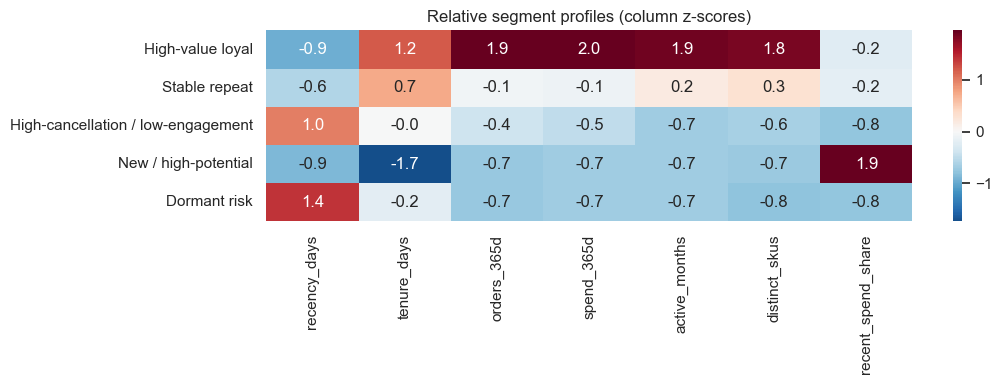

**Result interpretation:** The largest segment is **Dormant risk**, representing **36.7%**；The segment with the highest historical median spend is **High-value loyal**, with median spend of **£3,828**。The heatmap shows each segment relative to the others rather than absolute amounts. Operational names are generated by auditable relative rules; before deployment, the business team should still confirm that the language fits the brand and intended actions.

In [7]:
customers["cluster"] = kmeans.labels_
profile_cols = [
    "recency_days", "tenure_days", "orders_365d", "spend_365d", "avg_order_value",
    "active_months", "distinct_skus", "mean_order_gap_days",
    "recent_order_share", "recent_spend_share", "cancelled_invoice_rate", "is_uk"
]
profiles = customers.groupby("cluster").agg(
    customers=("orders_365d", "size"),
    **{col: (col, "median") for col in profile_cols}
).reset_index()
profiles["customer_share"] = profiles.customers / len(customers)

# Assign unique names from relative cross-segment profiles; names are operational labels, not natural personality types.
zcols = ["recency_days", "tenure_days", "orders_365d", "spend_365d", "active_months", "recent_spend_share"]
z = profiles.set_index("cluster")[zcols].apply(lambda s: (s - s.mean()) / (s.std(ddof=0) + 1e-9))
remaining = set(profiles.cluster)
name_map = {}

def assign_best(label, score):
    candidates = score.loc[list(remaining)]
    cluster = int(candidates.idxmax())
    name_map[cluster] = label
    remaining.remove(cluster)

assign_best("High-value loyal", z.spend_365d + z.orders_365d + z.active_months - z.recency_days)
if remaining:
    assign_best("Dormant risk", z.recency_days - z.recent_spend_share + .3 * z.tenure_days)
if remaining:
    assign_best("New / high-potential", -z.tenure_days - .5 * z.orders_365d - .3 * z.recency_days)
if remaining:
    cancel_rate = profiles.set_index("cluster").cancelled_invoice_rate
    cancel_z = (cancel_rate - cancel_rate.mean()) / (cancel_rate.std(ddof=0) + 1e-9)
    if cancel_rate.loc[list(remaining)].max() >= 0.15:
        assign_best("High-cancellation / low-engagement", cancel_z - .3 * z.spend_365d)
    else:
        assign_best("Low-engagement long tail", -z.spend_365d - z.orders_365d + .5 * z.recency_days)
fallback_names = ["Stable repeat", "Developing", "Other behavior"]
for cluster, label in zip(sorted(remaining, key=lambda c: z.loc[c, "spend_365d"], reverse=True), fallback_names):
    name_map[int(cluster)] = label

customers["segment"] = customers.cluster.map(name_map)
profiles["segment"] = profiles.cluster.map(name_map)
profiles = profiles.sort_values("spend_365d", ascending=False)
display(profiles[["cluster", "segment", "customers", "customer_share", *profile_cols]].style.format({
    "customers": "{:,.0f}", "customer_share": "{:.1%}", "recency_days": "{:,.0f}",
    "tenure_days": "{:,.0f}", "orders_365d": "{:,.0f}", "spend_365d": "£{:,.0f}",
    "avg_order_value": "£{:,.0f}", "active_months": "{:,.0f}", "distinct_skus": "{:,.0f}",
    "mean_order_gap_days": "{:,.1f}", "recent_order_share": "{:.1%}",
    "recent_spend_share": "{:.1%}", "cancelled_invoice_rate": "{:.1%}", "is_uk": "{:.1%}"
}))

heat_cols = ["recency_days", "tenure_days", "orders_365d", "spend_365d", "active_months", "distinct_skus", "recent_spend_share"]
heat = profiles.set_index("segment")[heat_cols]
heat_z = heat.apply(lambda s: (s - s.mean()) / (s.std(ddof=0) + 1e-9))
plt.figure(figsize=(11, max(4, SELECTED_K * .75)))
sns.heatmap(heat_z, cmap="RdBu_r", center=0, annot=True, fmt=".1f")
plt.title("Relative segment profiles (column z-scores)")
plt.xlabel(""); plt.ylabel(""); plt.tight_layout(); plt.show()

profiles.to_csv(OUTPUT_DIR / "customer_segment_profiles.csv", index=False)
centroids = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=CLUSTER_FEATURES)
centroids[LOG_FEATURES] = np.expm1(centroids[LOG_FEATURES]).clip(lower=0)
centroids.insert(0, "cluster", range(SELECTED_K))
centroids.insert(1, "segment", centroids.cluster.map(name_map))
centroids.to_csv(OUTPUT_DIR / "kmeans_centroids_transformed_back.csv", index=False)

largest = profiles.sort_values("customer_share", ascending=False).iloc[0]
highest = profiles.sort_values("spend_365d", ascending=False).iloc[0]
display(Markdown(
    f"**Result interpretation:** The largest segment is **{largest.segment}**, representing **{largest.customer_share:.1%}**；"
    f"The segment with the highest historical median spend is **{highest.segment}**, with median spend of **£{highest.spend_365d:,.0f}**。"
    "The heatmap shows each segment relative to the others rather than absolute amounts. "
    "Operational names are generated by auditable relative rules; before deployment, the business team should still confirm that the language fits the brand and intended actions."
))


## 8. Validate the segments with purchasing behavior during the next 90 days

,segment,customers,repurchase_rate_90d,average_future_orders_90d,average_future_spend_90d,median_future_spend_90d,repurchase_ci_low,repurchase_ci_high
2,High-value loyal,743,87.1%,3.52,"£2,339",£970,84.5%,89.3%
4,Stable repeat,"1,160",60.4%,1.04,£414,£216,57.6%,63.2%
3,New / high-potential,428,48.6%,1.05,£445,£0,43.9%,53.3%
1,High-cancellation / low-engagement,411,35.3%,0.59,£242,£0,30.8%,40.0%
0,Dormant risk,"1,593",27.9%,0.39,£127,£0,25.8%,30.2%


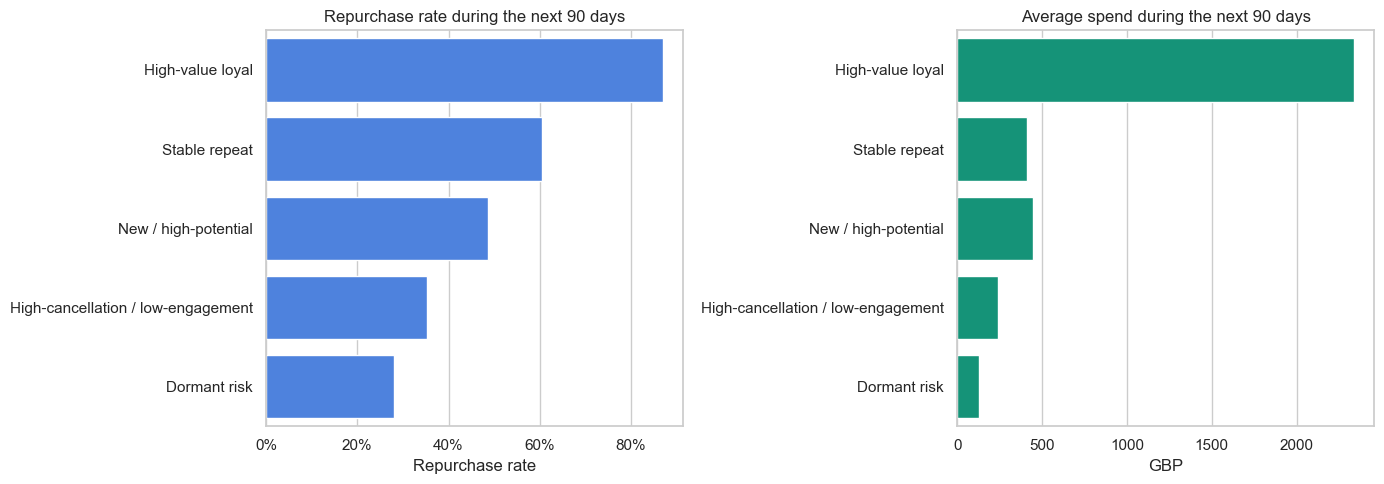

**Result interpretation:** **High-value loyal** has the highest 90-day repurchase rate at **87.1%**; **Dormant risk** has the lowest at **27.9%**。Future behavior was not used for clustering, so differences between segments provide out-of-sample business validation. The result remains observational: it shows that segment membership is associated with future behavior, not that issuing a coupon to a segment will causally increase repurchase.

In [8]:
future = successful.loc[
    (successful.invoice_date >= CUTOFF) & (successful.invoice_date < VALIDATION_END)
].copy()
future_orders = future.groupby(["customer_id", "invoice"], as_index=False).agg(
    order_value=("revenue", "sum")
).groupby("customer_id").agg(
    future_orders_90d=("invoice", "nunique"), future_spend_90d=("order_value", "sum")
)
validation = customers.join(future_orders, how="left")
validation[["future_orders_90d", "future_spend_90d"]] = validation[["future_orders_90d", "future_spend_90d"]].fillna(0)
validation["repurchased_90d"] = (validation.future_orders_90d > 0).astype(int)

future_profile = validation.groupby("segment").agg(
    customers=("repurchased_90d", "size"),
    repurchase_rate_90d=("repurchased_90d", "mean"),
    average_future_orders_90d=("future_orders_90d", "mean"),
    average_future_spend_90d=("future_spend_90d", "mean"),
    median_future_spend_90d=("future_spend_90d", "median")
).reset_index().sort_values("repurchase_rate_90d", ascending=False)

# Wilson 95% intervals show uncertainty in each segment's repurchase-rate estimate.
z95 = 1.96
p = future_profile.repurchase_rate_90d
n = future_profile.customers
denom = 1 + z95**2 / n
center = (p + z95**2 / (2*n)) / denom
margin = z95 * np.sqrt((p*(1-p) + z95**2/(4*n))/n) / denom
future_profile["repurchase_ci_low"] = center - margin
future_profile["repurchase_ci_high"] = center + margin

display(future_profile.style.format({
    "customers": "{:,.0f}", "repurchase_rate_90d": "{:.1%}",
    "average_future_orders_90d": "{:.2f}", "average_future_spend_90d": "£{:,.0f}",
    "median_future_spend_90d": "£{:,.0f}", "repurchase_ci_low": "{:.1%}", "repurchase_ci_high": "{:.1%}"
}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_order = future_profile.segment.tolist()
sns.barplot(data=future_profile, y="segment", x="repurchase_rate_90d", order=plot_order, ax=axes[0], color="#367BF5")
sns.barplot(data=future_profile, y="segment", x="average_future_spend_90d", order=plot_order, ax=axes[1], color="#00A884")
axes[0].set(title="Repurchase rate during the next 90 days", xlabel="Repurchase rate", ylabel="")
axes[0].xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
axes[1].set(title="Average spend during the next 90 days", xlabel="GBP", ylabel="")
plt.tight_layout(); plt.show()

future_profile.to_csv(OUTPUT_DIR / "segment_future_90d_validation.csv", index=False)
best = future_profile.iloc[0]
worst = future_profile.iloc[-1]
display(Markdown(
    f"**Result interpretation:** **{best.segment}** has the highest 90-day repurchase rate at **{best.repurchase_rate_90d:.1%}**; "
    f"**{worst.segment}** has the lowest at **{worst.repurchase_rate_90d:.1%}**。"
    "Future behavior was not used for clustering, so differences between segments provide out-of-sample business validation. "
    "The result remains observational: it shows that segment membership is associated with future behavior, not that issuing a coupon to a segment will causally increase repurchase."
))


## 9. Operational recommendations and limitations

### How the segments can enter operations

- **High-value loyal customers:** protect service quality, offer priority access, and avoid unnecessary blanket discounts;
- **Dormant-risk customers:** place eligible customers into a reactivation experiment, prioritized by historical value and contact cost;
- **New / high-potential customers:** improve second-order onboarding and category education;
- **High-cancellation / low-engagement customers:** investigate product and order issues before deciding on service recovery or low-cost outreach;
- **Stable or developing customers:** use relevant cross-sell and lifecycle content to deepen engagement.

### Limitations that must remain visible

1. Clusters depend on the observation window, feature set, scaling, and selected algorithm; they are not a unique truth.
2. Segment names are operational language, not customer personalities produced directly by the model.
3. The data do not include margin, campaign cost, or randomized assignment, so the project cannot estimate segment-level marketing ROI.
4. Future repurchase differences are predictive validation, not the causal effect of an intervention.
5. The public project contains several thousand customers and must not be presented as a 150,000+ customer project.

### Resume alignment

This project directly demonstrates:

> Applied K-Means and hierarchical clustering for user segmentation.

It also provides a reproducible Python pipeline from transaction cleaning and feature engineering through cluster-count selection, algorithm comparison, stability testing, and future-behavior validation. The website should describe it as demonstrating the same methodology on a public retail dataset.
